In [13]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from argparse import Namespace
from src.utils.plot import get_fig

all_df_list = []

In [14]:
df_list = []
loader = Path('logs/test').glob('*_single_K=10')
for path in sorted(loader, key=lambda x: x.stem):
    args = Namespace(**json.load(open(path / 'args.json', 'r')))
    record = pd.read_json(path / 'records.jsonl', lines=True)
    record = record[record['accuracy'].notna()].tail(1)
    df_list.append(record.assign(sample_num=args.sample_num, model='Ours'))
df_results = pd.concat(df_list, ignore_index=True)
display(df_results)
df_results = pd.DataFrame(dict(
    ped_num=np.concatenate(df_results['ped_num'].to_list()),
    rollout_time=np.concatenate(df_results['rollout_time'].to_list())*1000,
)).assign(model='Ours')
all_df_list.append(df_results)

,epoch,dataset_class,dataset_names,sample_nums,loss,ade,fde,trajlen,ped_num,veh_num,...,collision_ped,collision_veh,collision_map,norm_err,tan_err,accuracy,unweighted_accuracy,sample_num,model,apd
0,3031,[GC],[GC_20test],[2396],[0.11809217147973301],[0.189125753071226],[0.35367064603081105],[3.165455766647194],[44.01252086811352],[0.0],...,[0.18533236052485602],[None],[0.12245836989164101],[None],[None],0.940253,0.940253,10,Ours,NaN
1,3101,"[SDD, SDD, SDD, SDD, SDD, SDD, SDD, SDD, SDD, ...","[bookstore-4, bookstore-5, bookstore-6, coupa-...","[1137, 1019, 1165, 910, 17, 163, 612, 1152, 93...","[0.7885038161695551, 0.23306620360344701, 0.36...","[0.374624201024832, 0.23443758449627802, 0.269...","[0.703042853619922, 0.473236174350583, 0.51782...","[5.794048924706629, 3.311589359838141, 3.97080...","[3.50131926121372, 3.519136408243376, 3.632618...","[6.246262093227792, 4.8508341511285575, 1.5442...",...,"[0.013117491674512, 0.07411617178596, 0.019843...","[0.006559964257727001, None, None, None, 0.004...","[0.04812958363585, 0.015465977771546001, 0.042...","[None, 0.098136484622955, 0.031844113022089005...","[None, 0.08434542268514601, 0.045002799481153,...",0.936722,0.886783,10,Ours,NaN
2,1311,"[WayMo, WayMo, WayMo, WayMo, WayMo, WayMo, Way...","[00000_10_2bc07893b2abbb07_20test, 00000_11_54...","[6, 6, 5, 6, 6, 6, 6, 5, 6, 6, 6, 6, 2, 6, 6, ...","[0.127092057218154, 0.15096375346183702, 0.069...","[0.26629165851179204, 0.320859104394912, 0.197...","[0.5896975353317351, 0.641673586393396, 0.3313...","[5.449349468466879, 8.122514684995016, 5.71769...","[14.5, 5.0, 1.0, 3.0, 1.0, 5.0, 6.833333333333...","[9.0, 5.0, 1.0, 4.0, 7.0, 10.0, 4.0, 3.0, 5.0,...",...,"[0.0018658425348500002, 0.7177777687708531, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.165125459432601, 0.36381301283836304, 0.152...","[0.17167115211486803, 0.316803783178329, 0.031...",0.944954,0.942938,10,Ours,NaN
3,3121,[ETH],[eth],[821],[0.307576777184343],[0.526590574480024],[1.060530707772032],[9.297440112838899],[5.674786845310597],[0.0],...,[0.090396832865934],[None],[5.507806602697113e-06],[None],[None],0.943362,0.943362,10,Ours,[0.510786401615247]
4,3111,[ETH],[hotel],[1086],[0.26949051211131],[0.47326373683708306],[1.113516619658128],[4.217850570259792],[5.222836095764273],[0.0],...,[0.10887890973670301],[None],[0.0025691414448890003],[None],[None],0.887795,0.887795,10,Ours,NaN
5,3021,[UCY],[university_students-students003],[520],[0.244054604923495],[0.5565588454140971],[1.067507293095552],[4.565082501991238],[31.96153846153846],[0.0],...,[0.11201488155414902],[None],[0.007404977679111],[None],[None],0.878084,0.878084,10,Ours,NaN
6,2661,[UCY],[zara-crowds_zara01],[841],[0.044767223692783006],[0.146368268844977],[0.30728574849112905],[3.151030005939206],[5.658739595719382],[0.0],...,[0.30800901031992],[None],[0.011640864289448001],[None],[None],0.953549,0.953549,10,Ours,NaN
7,2531,[UCY],[zara-crowds_zara02],[1029],[1.237044131424707],[0.477659676527445],[1.031185131250076],[2.3825298086850353],[8.987366375121477],[0.0],...,[0.3085291792034],[None],[0.036952885528012],[None],[None],0.799516,0.799516,10,Ours,NaN


In [15]:
df_list = []
loader = Path('logs/train_social_stgcnn').glob('*_single_K=10')
for path in sorted(loader, key=lambda x: x.stem):
    args = Namespace(**json.load(open(path / 'args.json', 'r')))
    record = pd.read_json(path / 'records.jsonl', lines=True)
    record = record[record['accuracy'].notna()].tail(1)
    df_list.append(record.assign(sample_num=args.sample_num, model='Social-STGCNN'))
df_results = pd.concat(df_list, ignore_index=True)
display(df_results)
df_results = pd.DataFrame(dict(
    ped_num=np.concatenate(df_results['ped_num'].to_list()),
    rollout_time=np.concatenate(df_results['rollout_time'].to_list())*1000,
)).assign(model='Social-STGCNN')
all_df_list.append(df_results)

,loss,epoch,dataset_class,dataset_names,sample_nums,ade,fde,trajlen,ped_num,veh_num,rollout_time,collision_ped,collision_veh,collision_map,norm_err,tan_err,accuracy,unweighted_accuracy,sample_num,model
0,[None],60.0,[GC],[GC_80train_20eval],[1917],[0.49574921515777304],[0.9591092524313181],[3.9248709959744543],[168.06885758998436],[0.0],[4.235433726616682],[0.183224370919778],[None],[0.040790394313942005],[None],[None],0.873690,0.873690,10,Social-STGCNN
1,"[None, None, None, None, None, None, None, Non...",240.0,"[SDD, SDD, SDD, SDD, SDD, SDD, SDD, SDD, SDD, ...","[bookstore-0_20eval, bookstore-1_20eval, books...","[219, 231, 239, 239, 186, 174, 188, 208, 231, ...","[1.04274092091599, 0.7022320046510281, 0.99413...","[1.7856388960074332, 1.294089049701448, 1.6933...","[3.689830137360056, 3.627191077641101, 4.36764...","[5.853881278538813, 5.558441558441558, 7.24267...","[14.429223744292237, 10.012987012987013, 11.91...","[0.023498808412247003, 0.023754276754536, 0.02...","[0.015200255080402, 0.010018610285627, 0.03833...","[0.004723143386686, 0.002389054981794, 0.00568...","[0.063293590394047, 0.009361113974209, 0.00027...","[0.969362616539001, 0.594465494155883, 0.20276...","[0.6473644971847531, 0.462053686380386, 0.2022...",-343.453707,-196.585308,10,Social-STGCNN
2,"[None, None, None, None, None, None, None, Non...",1450.0,"[WayMo, WayMo, WayMo, WayMo, WayMo, WayMo, Way...","[00000_10_2bc07893b2abbb07_80train_20eval, 000...","[5, 5, 4, 5, 5, 5, 5, 4, 5, 5, 4, 5, 2, 5, 5, ...","[0.611271065214405, 0.786931386148488, 0.52187...","[1.071829239959302, 1.482749514005802, 1.07346...","[5.552594078191812, 7.771920345447682, 4.89299...","[13.8, 5.4, 1.0, 3.0, 1.6, 8.2, 7.6, 3.25, 2.0...","[10.0, 5.0, 1.0, 4.8, 8.0, 11.2, 4.0, 3.0, 5.0...","[0.05026364326477, 0.019122123718261, 0.017951...","[0.0, 0.339333337545394, 0.0, 0.0, 0.0, 0.0058...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.369674295186996, 2.178528547286987, None, 0...","[0.5036349296569821, 0.886956334114074, None, ...",0.843489,0.843512,10,Social-STGCNN
3,[None],330.0,[ETH],[eth],[821],[1.722989720567648],[3.411694441636155],[9.297440112838899],[5.674786845310597],[0.0],[0.03317711414286],[0.106567950127192],[None],[0.0],[None],[None],0.814681,0.814681,10,Social-STGCNN
4,[None],150.0,[ETH],[hotel],[1086],[1.367439814668532],[2.595577859295199],[4.217850570259792],[5.222836095764273],[0.0],[0.015398712887070001],[0.08824803336209601],[None],[0.005278136380349001],[None],[None],0.675797,0.675797,10,Social-STGCNN
5,[None],300.0,[UCY],[university_students-students003],[520],[0.9373867017982431],[1.916739209168383],[4.565082501991238],[31.96153846153846],[0.0],[0.066619884509306],[0.11360946589758401],[None],[0.008083320024486],[None],[None],0.794662,0.794662,10,Social-STGCNN
6,[None],330.0,[UCY],[zara-crowds_zara01],[841],[0.417887044122963],[0.7688064914859941],[3.151030005939206],[5.658739595719382],[0.0],[0.017574986719773002],[0.21939471387498102],[None],[0.018114810677395],[None],[None],0.867381,0.867381,10,Social-STGCNN
7,[None],820.0,[UCY],[zara-crowds_zara02],[1029],[0.6647492127076501],[1.18198244103925],[2.3825298086850353],[8.987366375121477],[0.0],[0.021370284874770003],[0.37905039292768306],[None],[0.023256768705108],[None],[None],0.720990,0.720990,10,Social-STGCNN


In [23]:
df_list = []
loader = Path('logs/train_spdiff').glob('*_single_K=10')
for path in sorted(loader, key=lambda x: x.stem):
    args = Namespace(**json.load(open(path / 'args.json', 'r')))
    record = pd.read_json(path / 'records.jsonl', lines=True)
    record = record[record['accuracy'].notna()].tail(1)
    df_list.append(record.assign(sample_num=args.sample_num, model='MID'))
df_results = pd.concat(df_list, ignore_index=True)
display(df_results)
df_results = pd.DataFrame(dict(
    ped_num=np.concatenate(df_results['ped_num'].to_list()),
    rollout_time=np.concatenate(df_results['rollout_time'].to_list())*1000,
)).assign(model='MID')
# all_df_list.append(df_results)

KeyError: 'accuracy'

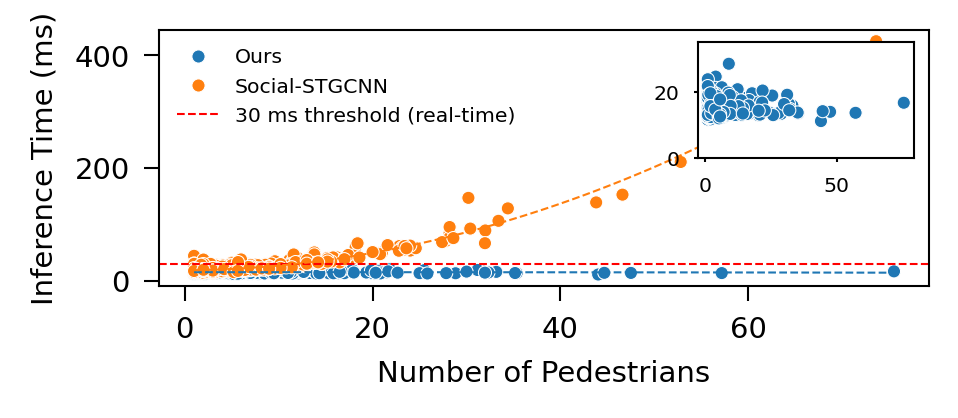

In [54]:
df_plot = pd.concat(all_df_list, ignore_index=True)
df_plot = df_plot[df_plot['ped_num'] <= 100]

fi, fig, axes = get_fig(1, 1, FW=8, A_ratio=3.0, HS=5)

ax = axes[0]
sns.scatterplot(
    data=df_plot,
    x='ped_num',
    y='rollout_time',
    hue='model',
    s=10,
    rasterized=True,
)
ax.axhline(y=30, color='red', linestyle='--', label='30 ms threshold (real-time)')
ax.legend(title=None, frameon=False, loc='upper left', fontsize=0.7*fi['fontsize'])
ax.set_xlabel('Number of Pedestrians')
ax.set_ylabel('Inference Time (ms)')

x = df_plot[df_plot['model'] == 'Ours']['ped_num'].values
y = df_plot[df_plot['model'] == 'Ours']['rollout_time'].values
coefficients = np.polyfit(x, y, 2)
polynomial = np.poly1d(coefficients)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = polynomial(x_fit)
ax.plot(x_fit, y_fit, color='C0', linestyle='--', label='Ours Fit')

x = df_plot[df_plot['model'] == 'Social-STGCNN']['ped_num'].values
y = df_plot[df_plot['model'] == 'Social-STGCNN']['rollout_time'].values
coefficients = np.polyfit(x, y, 2)
polynomial = np.poly1d(coefficients)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = polynomial(x_fit)
ax.plot(x_fit, y_fit, color='C1', linestyle='--', label='Social-STGCNN Fit')

x, y, w, h = ax.get_position().bounds
sub_ax = fig.add_axes([x+0.7*w, y+0.5*h, 0.28*w, 0.45*h])
sns.scatterplot(
    data=df_plot[df_plot['model'] == 'Ours'],
    x='ped_num',
    y='rollout_time',
    hue='model',
    s=10,
    ax=sub_ax,
    legend=False,
    rasterized=True,
)
sub_ax.set_xlabel('')
sub_ax.set_ylabel('')
sub_ax.tick_params(labelsize=fi['fontsize']*0.7, length=1)
sub_ax.set_ylim(0, 35)

fig.savefig('figures/vary_pedestrian_num.png', dpi=300, transparent=True, bbox_inches='tight')
fig.savefig('figures/vary_pedestrian_num.pdf', dpi=300, transparent=True, bbox_inches='tight')
fig.savefig('figures/vary_pedestrian_num.svg', dpi=300, transparent=True, bbox_inches='tight')